<a href="https://colab.research.google.com/github/Asritha0507/ML-Market-Basket-Analysis/blob/main/06_Top_K_Recommendation_and_Ranking_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

base_path = "/content/drive/MyDrive/ML_Market_Basket_Analysis"

possible_paths = [
    f"{base_path}/Models/xgboost_next_basket_ranker.json",
    f"{base_path}/Datasets/Model_Outputs/xgboost_next_basket_ranker.json"
]

for path in possible_paths:
    print(path)
    print("Exists:", os.path.exists(path))
    print()

/content/drive/MyDrive/ML_Market_Basket_Analysis/Models/xgboost_next_basket_ranker.json
Exists: False

/content/drive/MyDrive/ML_Market_Basket_Analysis/Datasets/Model_Outputs/xgboost_next_basket_ranker.json
Exists: False



In [ ]:
import os

project_path = "/content/drive/MyDrive/ML_Market_Basket_Analysis"

model_files = []

for root, dirs, files in os.walk(project_path):
    for file in files:
        if file.endswith(".json") and "xgboost" in file.lower():
            model_files.append(os.path.join(root, file))

print("XGBoost model files found:", len(model_files))

for f in model_files:
    print(f)

XGBoost model files found: 0


In [ ]:
import pandas as pd
import numpy as np
import os
import gc
import xgboost as xgb

base_path = "/content/drive/MyDrive/ML_Market_Basket_Analysis"
engineered_path = f"{base_path}/Datasets/Engineered_Features"
models_path = f"{base_path}/Models/Model_Outputs"
output_path = f"{base_path}/Datasets/Model_Outputs"

model_path = f"{models_path}/xgboost_next_basket_ranker.json"

model = xgb.XGBRanker()
model.load_model(model_path)

print("Notebook 6 started successfully.")
print("XGBoost version:", xgb.__version__)
print("Model loaded successfully.")
print("Model file exists:", os.path.exists(model_path))
print("Engineered features folder exists:", os.path.exists(engineered_path))

XGBoostError: [12:41:12] /__w/xgboost/xgboost/src/common/io.cc:144: Opening /content/drive/MyDrive/ML_Market_Basket_Analysis/Models/Model_Outputs/xgboost_next_basket_ranker.json failed: No such file or directory
Stack trace:
  [bt] (0) /usr/local/lib/python3.13/dist-packages/xgboost/lib/libxgboost.so(+0x21ec5c) [0x7d4d0ce1ec5c]
  [bt] (1) /usr/local/lib/python3.13/dist-packages/xgboost/lib/libxgboost.so(+0x33cb83) [0x7d4d0cf3cb83]
  [bt] (2) /usr/local/lib/python3.13/dist-packages/xgboost/lib/libxgboost.so(+0x133de7) [0x7d4d0cd33de7]
  [bt] (3) /usr/local/lib/python3.13/dist-packages/xgboost/lib/libxgboost.so(XGBoosterLoadModel+0xbe) [0x7d4d0cd3421e]
  [bt] (4) /lib/x86_64-linux-gnu/libffi.so.8(+0x7b16) [0x7d4d4dc52b16]
  [bt] (5) /lib/x86_64-linux-gnu/libffi.so.8(+0x43ef) [0x7d4d4dc4f3ef]
  [bt] (6) /lib/x86_64-linux-gnu/libffi.so.8(ffi_call+0x12e) [0x7d4d4dc520be]
  [bt] (7) /usr/lib/python3.13/lib-dynload/_ctypes.cpython-313-x86_64-linux-gnu.so(+0x16d26) [0x7d4d4dc0ad26]
  [bt] (8) 

In [ ]:
import glob

engineered_files = sorted(
    glob.glob(f"{engineered_path}/engineered_candidate_chunk_*.parquet")
)

np.random.seed(42)

all_validation_orders = []

for f in engineered_files:
    df = pd.read_parquet(
        f,
        columns=["order_id", "order_number"]
    )
    ids = df.loc[df["order_number"] >= 51, "order_id"].unique()
    all_validation_orders.extend(ids)

all_validation_orders = np.unique(all_validation_orders)

sample_validation_orders = np.random.choice(
    all_validation_orders,
    size=1000,
    replace=False
)

print("Validation orders available:", len(all_validation_orders))
print("Validation orders selected:", len(sample_validation_orders))

Validation orders available: 11677
Validation orders selected: 1000


In [ ]:
recommendation_parts = []

selected_orders = set(sample_validation_orders)

for f in engineered_files:
    df = pd.read_parquet(f)

    part = df[df["order_id"].isin(selected_orders)].copy()

    if len(part) > 0:
        recommendation_parts.append(part)

    del df, part
    gc.collect()

recommendation_data = pd.concat(
    recommendation_parts,
    ignore_index=True
)

print("Recommendation data shape:", recommendation_data.shape)
print("Target orders:", recommendation_data["order_id"].nunique())
print("Positive products:", recommendation_data["in_next_basket"].sum())
print("Missing values:", recommendation_data.isna().sum().sum())

Recommendation data shape: (194638, 21)
Target orders: 1000
Positive products: 9369
Missing values: 0


In [ ]:
feature_cols = [
    "order_number",
    "order_dow",
    "order_hour_of_day",
    "days_since_prior_order",
    "times_purchased_before",
    "first_purchase_before",
    "last_purchase_before",
    "recency_before",
    "purchase_span_before",
    "was_previously_purchased",
    "aisle_id",
    "department_id",
    "previous_orders",
    "avg_basket_before",
    "max_basket_before",
    "total_items_before",
    "order_progress"
]

print("Number of model features:", len(feature_cols))
print("All features available:", all(
    col in recommendation_data.columns for col in feature_cols
))

Number of model features: 17
All features available: True


In [ ]:
X_recommend = recommendation_data[feature_cols]

recommendation_data["recommendation_score"] = model.predict(
    X_recommend
)

print("Recommendation scores generated successfully.")
print(
    "Score range:",
    round(recommendation_data["recommendation_score"].min(), 4),
    "to",
    round(recommendation_data["recommendation_score"].max(), 4)
)

Recommendation scores generated successfully.
Score range: -5.0289 to 4.9619


In [ ]:
top_k = 20

top_recommendations = (
    recommendation_data
    .sort_values(
        ["order_id", "recommendation_score"],
        ascending=[True, False]
    )
    .groupby("order_id", sort=False)
    .head(top_k)
    .copy()
)

top_recommendations["rank"] = (
    top_recommendations
    .groupby("order_id")
    .cumcount() + 1
)

print("Top recommendations generated.")
print("Orders:", top_recommendations["order_id"].nunique())
print("Recommendation rows:", len(top_recommendations))
print("Maximum rank:", top_recommendations["rank"].max())

print("\nRecommendations per order:")
print(top_recommendations.groupby("order_id").size().value_counts().sort_index())

Top recommendations generated.
Orders: 1000
Recommendation rows: 20000
Maximum rank: 20

Recommendations per order:
20    1000
Name: count, dtype: int64


In [ ]:
products_path = f"{base_path}/Datasets/products.csv"

products = pd.read_csv(products_path, usecols=["product_id", "product_name"])

sample_order_id = top_recommendations["order_id"].iloc[0]

sample_recommendations = (
    top_recommendations[
        top_recommendations["order_id"] == sample_order_id
    ]
    .merge(products, on="product_id", how="left")
    [["rank", "product_id", "product_name", "recommendation_score", "in_next_basket"]]
    .sort_values("rank")
)

print("Sample Order ID:", sample_order_id)
print()
print(sample_recommendations.to_string(index=False))

Sample Order ID: 3916

 rank  product_id                                       product_name  recommendation_score  in_next_basket
    1       43545                             Organic Coconut Yogurt              3.464279               1
    2       13176                             Bag of Organic Bananas              3.423945               1
    3        4793                                Wild Berry Smoothie              2.776508               1
    4       25931                         Organic Baby Spinach Salad              2.589228               0
    5        9839                                   Organic Broccoli              2.061284               1
    6       28597                 Organic Stoneground Wheat Crackers              2.000605               0
    7       17795                         Organic Green Leaf Lettuce              1.713794               0
    8       44359                         Organic Small Bunch Celery              1.445639               0
    9       24

In [ ]:
def calculate_metrics(df, k):
    metrics = []

    for order_id, group in df.groupby("order_id"):
        top_k = group[group["rank"] <= k]
        actual = group["in_next_basket"].sum()

        hits = top_k["in_next_basket"].sum()

        precision = hits / k
        recall = hits / actual if actual > 0 else 0

        gains = top_k["in_next_basket"].values
        dcg = sum(
            gain / np.log2(rank + 1)
            for rank, gain in enumerate(gains, start=1)
        )

        ideal_gains = sorted(
            group["in_next_basket"].values,
            reverse=True
        )[:k]

        idcg = sum(
            gain / np.log2(rank + 1)
            for rank, gain in enumerate(ideal_gains, start=1)
        )

        ndcg = dcg / idcg if idcg > 0 else 0

        metrics.append([precision, recall, ndcg])

    return np.mean(metrics, axis=0)


for k in [5, 10, 20]:
    precision, recall, ndcg = calculate_metrics(
        top_recommendations,
        k
    )

    print(f"Top-{k}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"NDCG:      {ndcg:.4f}")
    print()

Top-5
Precision: 0.5958
Recall:    0.5558
NDCG:      0.7184

Top-10
Precision: 0.4617
Recall:    0.7883
NDCG:      0.7602

Top-20
Precision: 0.3135
Recall:    1.0000
NDCG:      0.8504



In [ ]:
order_performance = (
    top_recommendations
    .groupby("order_id")
    .apply(
        lambda x: pd.Series({
            "actual_products": int(x["in_next_basket"].sum()),
            "hits_top5": int(x.loc[x["rank"] <= 5, "in_next_basket"].sum()),
            "hits_top10": int(x.loc[x["rank"] <= 10, "in_next_basket"].sum()),
            "hits_top20": int(x.loc[x["rank"] <= 20, "in_next_basket"].sum())
        }),
        include_groups=False
    )
    .reset_index()
)

print("Per-order analysis created.")
print()
print(order_performance.describe())

print("\nOrders with at least one hit:")
for k in [5, 10, 20]:
    count = (order_performance[f"hits_top{k}"] > 0).sum()
    percentage = count / len(order_performance) * 100
    print(f"Top-{k}: {count}/{len(order_performance)} ({percentage:.2f}%)")

Per-order analysis created.

           order_id  actual_products    hits_top5   hits_top10   hits_top20
count  1.000000e+03      1000.000000  1000.000000  1000.000000  1000.000000
mean   1.744252e+06         6.269000     2.979000     4.617000     6.269000
std    9.726067e+05         3.452036     1.318445     2.237704     3.452036
min    3.916000e+03         1.000000     0.000000     0.000000     1.000000
25%    9.129990e+05         4.000000     2.000000     3.000000     4.000000
50%    1.760694e+06         6.000000     3.000000     4.000000     6.000000
75%    2.565775e+06         8.000000     4.000000     6.000000     8.000000
max    3.420793e+06        19.000000     5.000000    10.000000    19.000000

Orders with at least one hit:
Top-5: 977/1000 (97.70%)
Top-10: 995/1000 (99.50%)
Top-20: 1000/1000 (100.00%)


In [ ]:
import os

os.makedirs(output_path, exist_ok=True)

recommendation_output_path = f"{output_path}/top20_recommendations_1000_validation_orders.csv"

top_recommendations.to_csv(
    recommendation_output_path,
    index=False
)

print("Top-20 recommendations saved successfully.")
print("File:", recommendation_output_path)
print("Rows:", len(top_recommendations))
print("Orders:", top_recommendations["order_id"].nunique())

Top-20 recommendations saved successfully.
File: /content/drive/MyDrive/ML_Market_Basket_Analysis/Datasets/Model_Outputs/top20_recommendations_1000_validation_orders.csv
Rows: 20000
Orders: 1000


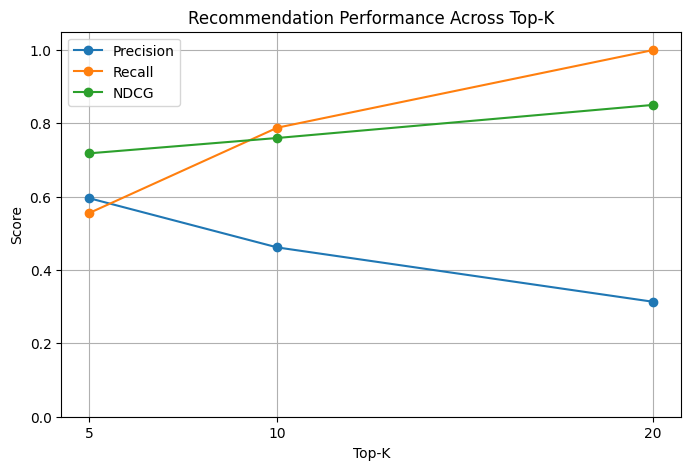

In [ ]:
import matplotlib.pyplot as plt

k_values = [5, 10, 20]
precision_values = [0.5958, 0.4617, 0.3135]
recall_values = [0.5558, 0.7883, 1.0000]
ndcg_values = [0.7184, 0.7602, 0.8504]

plt.figure(figsize=(8, 5))

plt.plot(k_values, precision_values, marker="o", label="Precision")
plt.plot(k_values, recall_values, marker="o", label="Recall")
plt.plot(k_values, ndcg_values, marker="o", label="NDCG")

plt.xlabel("Top-K")
plt.ylabel("Score")
plt.title("Recommendation Performance Across Top-K")
plt.xticks(k_values)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)

plt.show()